In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.io
from scipy.ndimage import uniform_filter, binary_closing, label

In [7]:
# workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML" 
workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

# Log data

In [27]:
ds = sorted(
        os.listdir(
            os.path.join(data_workspace, "alvin_edited_files/log_mapping/real/2s1")
    ))[0]
image = np.load(os.path.join(data_workspace, "alvin_edited_files/log_mapping/real/2s1", ds))

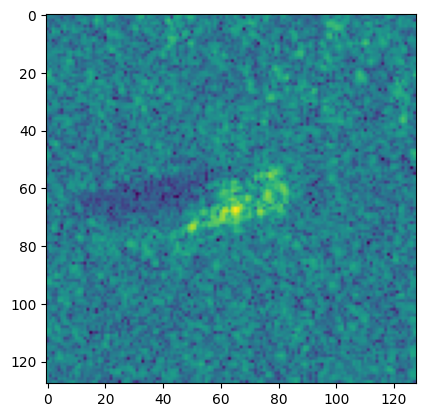

In [28]:
plt.imshow(image)
plt.show()

In [29]:
def readjust_intensity(image):
    return image / image.sum()

In [30]:
image_step0 = readjust_intensity(image)

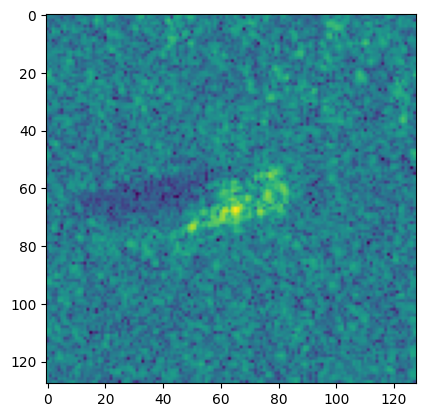

In [31]:
plt.imshow(image_step0)
plt.show()

In [49]:
def find_target_and_shadow_mask(image_step0):
    target_step1 = np.where(image_step0 >= np.percentile(image_step0, 90), 1, 0)
    shadow_step1 = np.where(image_step0 <= np.percentile(image_step0, 25), 1, 0)
    return target_step1, shadow_step1

In [52]:
target_step1, shadow_step1 = find_target_and_shadow_mask(image_step0)

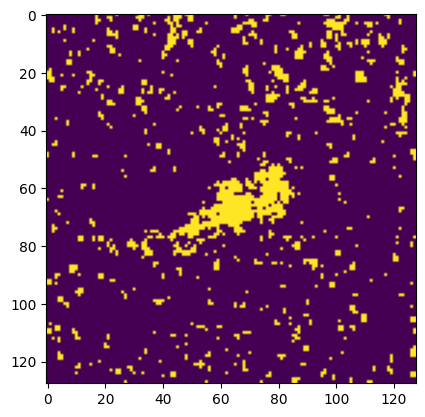

In [53]:
plt.imshow(target_step1)
plt.show()

In [54]:
def counting_filter(mask, window_size = 5, threshold = 15):
    neighbor_count = uniform_filter(mask.astype(float), size = window_size) * (window_size ** 2)
    return np.where(neighbor_count >= threshold, 1, 0)

In [55]:
target_step2, shadow_step2 = counting_filter(target_step1), counting_filter(shadow_step1)

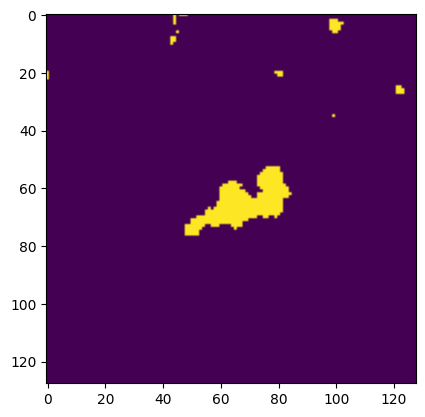

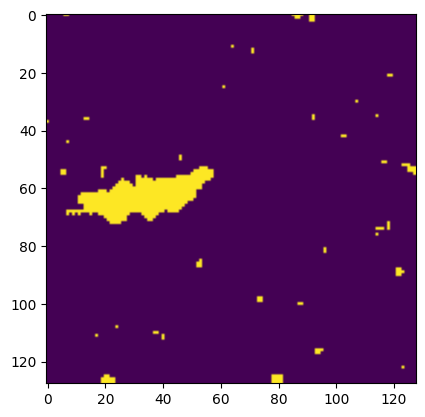

In [56]:
plt.imshow(target_step2)
plt.show()
plt.imshow(shadow_step2)
plt.show()

In [57]:
def structing_ele(shape = 5):
    ele = np.ones((shape, shape))
    ele[0, 0] = 0
    ele[0, -1] = 0
    ele[-1, 0] = 0
    ele[-1, -1] = 0
    return ele
def morphological_closing(mask, structuring_element = None):
    if structuring_element is None:
        structuring_element = structing_ele(shape = 5)
    return binary_closing(mask, structure = structuring_element).astype(bool)

In [58]:
target_step3, shadow_step3 = morphological_closing(target_step2), morphological_closing(shadow_step2)

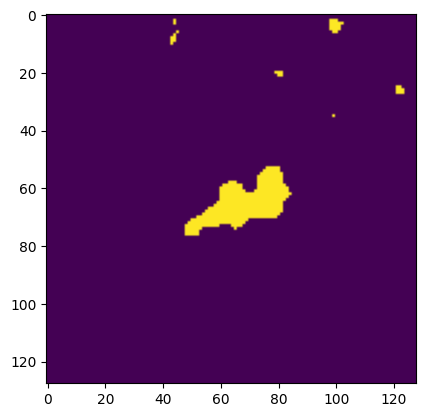

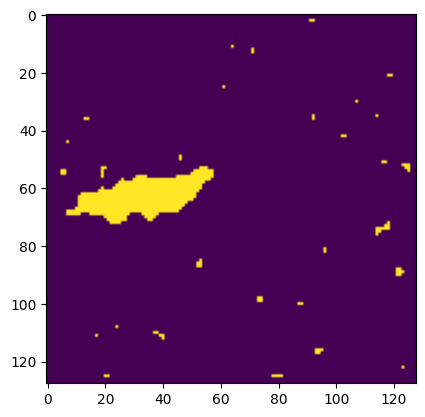

In [59]:
plt.imshow(target_step3)
plt.show()
plt.imshow(shadow_step3)
plt.show()

In [60]:
def find_largest_connected_component(mask):
    labeled_array, num_features = label(mask)
    if num_features == 0:
        return np.zeros_like(mask)
    largest_component = np.argmax(np.bincount(labeled_array.flat)[1:]) + 1
    return (labeled_array == largest_component).astype(int)

In [61]:
target_step4, shadow_step4 = find_largest_connected_component(target_step3), find_largest_connected_component(shadow_step3)

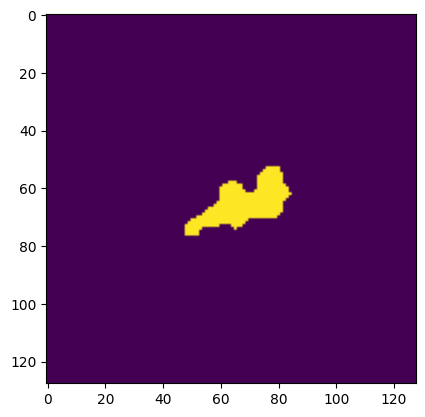

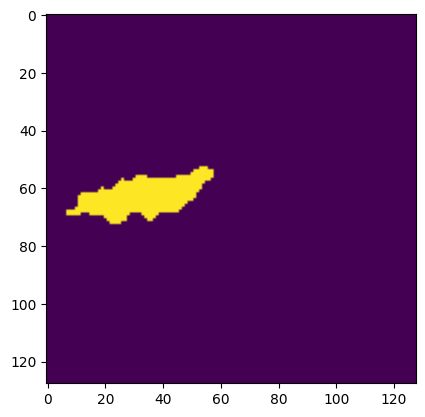

In [62]:
plt.imshow(target_step4)
plt.show()
plt.imshow(shadow_step4)
plt.show()

In [63]:
def mask_to_intensity(mask, image_step0):
    return mask * image_step0

In [64]:
target_step5, shadow_step5 = mask_to_intensity(target_step4, image_step0), mask_to_intensity(shadow_step4, image_step0)

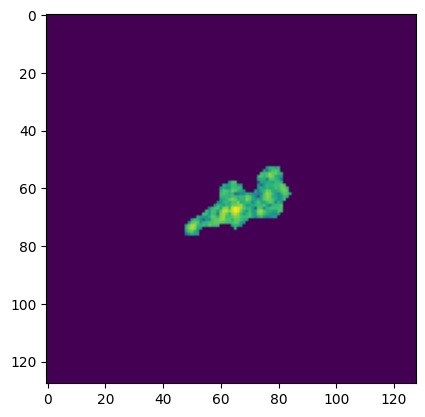

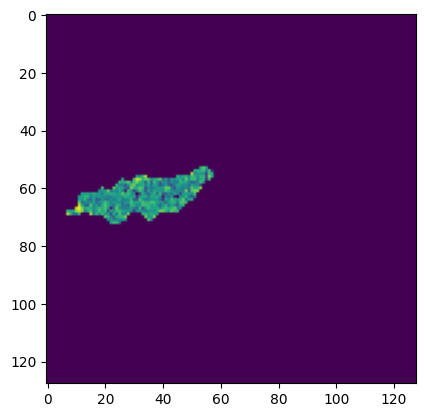

In [65]:
plt.imshow(target_step5)
plt.show()
plt.imshow(shadow_step5)
plt.show()

In [66]:
def choi_segmentation(image):
    image_step0 = readjust_intensity(image)
    target_step1, shadow_step1 = find_target_and_shadow_mask(image_step0)
    target_step2, shadow_step2 = counting_filter(target_step1), counting_filter(shadow_step1)
    target_step3, shadow_step3 = morphological_closing(target_step2), morphological_closing(shadow_step2)
    target_step4, shadow_step4 = find_largest_connected_component(target_step3), find_largest_connected_component(shadow_step3)
    clutter = 1 - (target_step4 + shadow_step4)
    # target_step5, shadow_step5 = mask_to_intensity(target_step4, image_step0), mask_to_intensity(shadow_step4, image_step0)
    return target_step4, shadow_step4, clutter

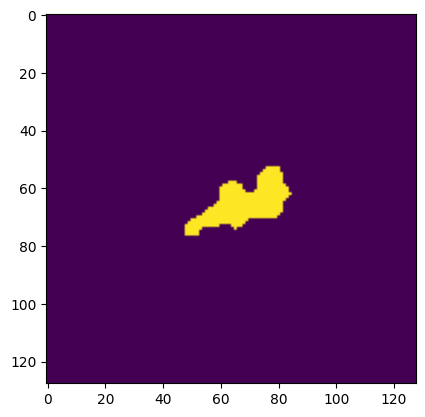

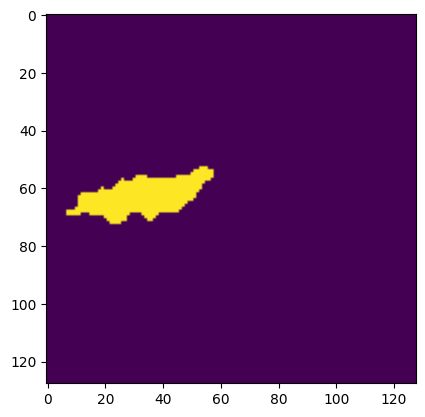

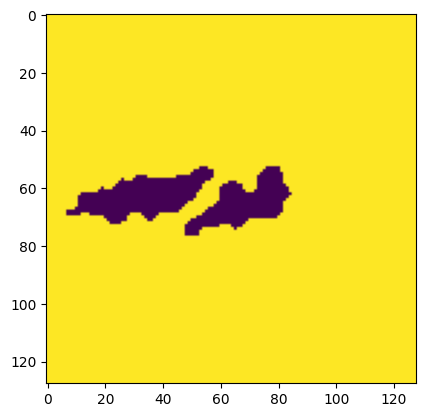

In [67]:
i, j, k = choi_segmentation(image)
plt.imshow(i)
plt.show()
plt.imshow(j)
plt.show()
plt.imshow(k)
plt.show()

# Linear scale

In [24]:
def mat_file_loader(path):
    """
    Custom loader function for DatasetFolder.
    Replaces your open_mat_file().
    
    Args:
        path: Path to .mat file
    Returns:
        complex_data: Complex numpy array from .mat file
    """
    mat_contents = scipy.io.loadmat(path)
    return mat_contents['complex_img']

class Magnitude:
    """
    Transform: extract magnitude.
    """
    def __call__(self, complex_data_or_tuple):
        """
        Args:
            complex_data: Complex numpy array from .mat file
        Returns:
            magnitude: Magnitude as numpy array
        """
        # Handle both: raw image OR (image, filepath) tuple
        if isinstance(complex_data_or_tuple, tuple):
            complex_data, filepath = complex_data_or_tuple
            pass_along = True
        else:
            complex_data = complex_data_or_tuple
            filepath = None
            pass_along = False
            
        magnitude = np.abs(complex_data)
        
        return (magnitude, filepath) if pass_along else magnitude

def readjust_intensity(image):
    return image / image.sum()

def find_target_and_shadow_mask(image_step0):
    target_step1 = np.where(image_step0 >= np.percentile(image_step0, 85), 1, 0)
    shadow_step1 = np.where(image_step0 <= np.percentile(image_step0, 30), 1, 0)
    return target_step1, shadow_step1

def counting_filter(mask, window_size = 5, threshold = 15):
    neighbor_count = uniform_filter(mask.astype(float), size = window_size) * (window_size ** 2)
    return np.where(neighbor_count >= threshold, 1, 0)

def structing_ele(shape = 5):
    ele = np.ones((shape, shape))
    ele[0, 0] = 0
    ele[0, -1] = 0
    ele[-1, 0] = 0
    ele[-1, -1] = 0
    return ele
def morphological_closing(mask, structuring_element = None):
    if structuring_element is None:
        structuring_element = structing_ele(shape = 5)
    return binary_closing(mask, structure = structuring_element).astype(bool)

def find_largest_connected_component(mask):
    labeled_array, num_features = label(mask)
    if num_features == 0:
        return np.zeros_like(mask)
    largest_component = np.argmax(np.bincount(labeled_array.flat)[1:]) + 1
    return (labeled_array == largest_component).astype(int)

def choi_segmentation(image):
    image_step0 = readjust_intensity(image)
    target_step1, shadow_step1 = find_target_and_shadow_mask(image_step0)
    target_step2, shadow_step2 = counting_filter(target_step1), counting_filter(shadow_step1)
    target_step3, shadow_step3 = morphological_closing(target_step2), morphological_closing(shadow_step2)
    target_step4, shadow_step4 = find_largest_connected_component(target_step3), find_largest_connected_component(shadow_step3)
    clutter = 1 - (target_step4 + shadow_step4)
    # target_step5, shadow_step5 = mask_to_intensity(target_step4, image_step0), mask_to_intensity(shadow_step4, image_step0)
    return target_step4, shadow_step4, clutter

In [25]:
ds = sorted(
        os.listdir(
            os.path.join(data_workspace, "mat_files/real/2s1")
    ))[0]
image = mat_file_loader(os.path.join(data_workspace, "mat_files/real/2s1", ds))
image = Magnitude()(image)

In [26]:
image

array([[0.04391003, 0.04986394, 0.03274647, ..., 0.0707026 , 0.06177174,
        0.03870037],
       [0.04093308, 0.03051375, 0.03274647, ..., 0.03200223, 0.02679256,
        0.02604833],
       [0.01860595, 0.01711747, 0.01041933, ..., 0.06846988, 0.03497918,
        0.00669814],
       ...,
       [0.06400446, 0.00744238, 0.04242156, ..., 0.04688698, 0.09675092,
        0.0982394 ],
       [0.06251598, 0.02381561, 0.015629  , ..., 0.02902528, 0.05953903,
        0.06623717],
       [0.04242156, 0.02604833, 0.04614275, ..., 0.0550736 , 0.03497918,
        0.00893085]], shape=(128, 128))

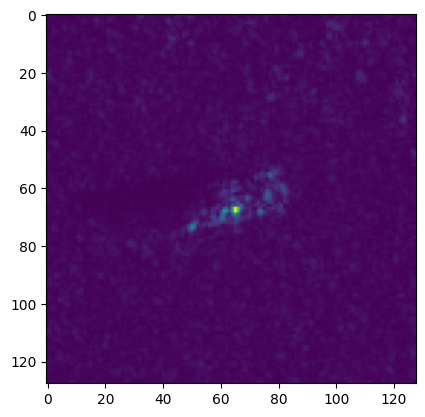

In [27]:
plt.imshow(image)
plt.show()

In [28]:
image1 = readjust_intensity(image)
i1, j1 = find_target_and_shadow_mask(image1)
i2, j2 = counting_filter(i1), counting_filter(j1)
i3, j3 = morphological_closing(i2), morphological_closing(j2)

In [29]:
i, j, k = choi_segmentation(image)

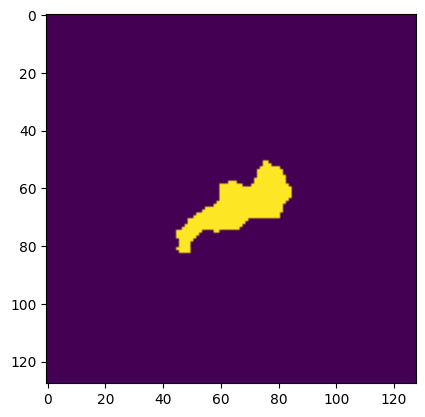

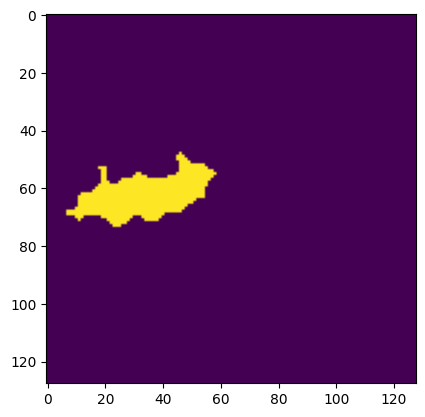

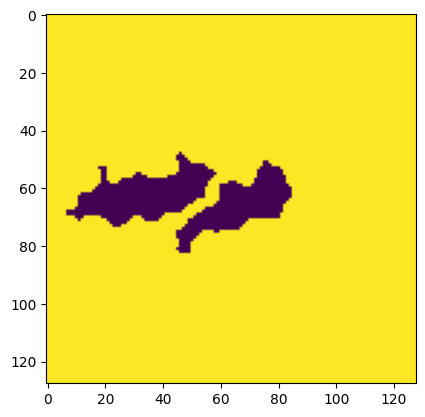

In [30]:
plt.imshow(i)
plt.show()
plt.imshow(j)
plt.show()
plt.imshow(k)
plt.show()